# Week 2: Model Evaluation

This notebook compares Bag-of-Words and TF-IDF features with Naive Bayes and Logistic Regression, tunes the strongest combination, saves the final model, and runs sample predictions.

In [1]:
from pathlib import Path
import sys
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from features import load_cleaned_dataset  # type: ignore[reportMissingImports]
from train_model import compare_models, tune_and_save  # type: ignore[reportMissingImports]

DATA_PATH = PROJECT_ROOT / 'data' / 'spam_cleaned.csv'
MODEL_PATH = PROJECT_ROOT / 'models' / 'spam_classifier.pkl'

if DATA_PATH.exists():
    dataset = load_cleaned_dataset(DATA_PATH)
    print(f'Loaded Week 1 dataset: {DATA_PATH}')
else:
    demo_rows = [
        ('win a free cash prize claim now', 1), ('urgent reward selected click link', 1),
        ('congratulations receive bonus money today', 1), ('exclusive offer reply to win', 1),
        ('free vacation call now limited offer', 1), ('you have won a shopping voucher', 1),
        ('claim your prize before it expires', 1), ('special promotion earn cash instantly', 1),
        ('winner chosen for a free gift', 1), ('act now to receive your reward', 1),
        ('project meeting is scheduled tomorrow', 0), ('please send the report this afternoon', 0),
        ('your appointment is confirmed for monday', 0), ('can you share the class notes', 0),
        ('the team lunch starts at noon', 0), ('thanks for sending the updated document', 0),
        ('the train will arrive at six', 0), ('please review the attached homework', 0),
        ('our call is moved to next week', 0), ('see you at the office tomorrow', 0),
    ]
    dataset = pd.DataFrame(demo_rows, columns=['clean_text', 'label_binary'])
    print('WARNING: spam_cleaned.csv is missing; using embedded demo data.')

print(f'Rows: {len(dataset):,}')
print(dataset['label_binary'].value_counts().rename(index={0: 'ham', 1: 'spam'}))

Loaded Week 1 dataset: D:\Internship-Weekly-Logs\week-2\data\spam_cleaned.csv
Rows: 5,162
label_binary
ham     4509
spam     653
Name: count, dtype: int64


In [2]:
results, fitted, (y_test, test_texts) = compare_models(dataset)
# Display results (without .style for compatibility)
print("Model Evaluation Results:")
print(results.to_string())
best = results.iloc[0]
print(f"\nBest baseline: {best['model']} with {best['features'].upper()} features; F1={best['f1']:.4f}")

Model Evaluation Results:


  features                model  accuracy  precision    recall        f1
0      bow          Naive Bayes  0.981607   0.930769  0.923664  0.927203
1      bow  Logistic Regression  0.980639   0.991150  0.854962  0.918033
2    tfidf          Naive Bayes  0.970958   1.000000  0.770992  0.870690
3    tfidf  Logistic Regression  0.960310   0.978723  0.702290  0.817778

Best baseline: Naive Bayes with BOW features; F1=0.9272


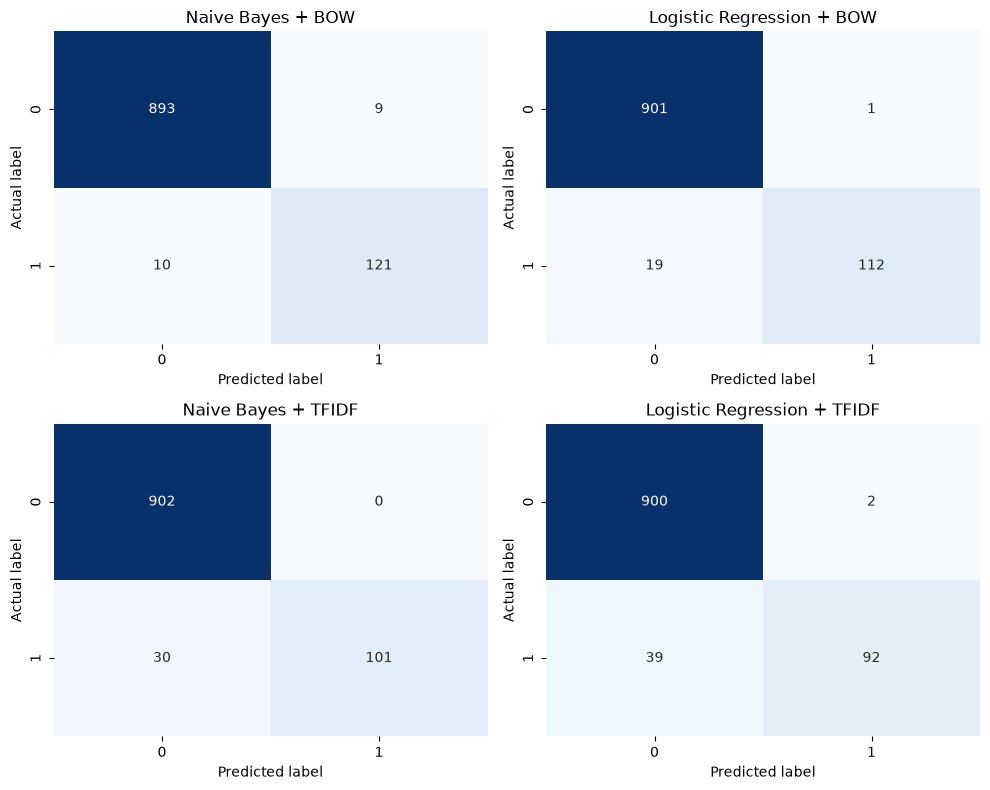

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for axis, ((feature_name, model_name), (vectorizer, model)) in zip(axes.ravel(), fitted.items()):
    predictions = model.predict(vectorizer.transform(test_texts))
    sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(f'{model_name} + {feature_name.upper()}')
    axis.set_xlabel('Predicted label')
    axis.set_ylabel('Actual label')
plt.tight_layout()
plt.show()

## Tuning and final model

F1-score is used to balance missed spam and false alarms. The selected baseline is tuned with cross-validation, then the saved artifact is evaluated on the held-out test split.

In [4]:
artifact, results = tune_and_save(dataset, MODEL_PATH)
print('Selected model:', artifact['model_name'])
print('Features:', artifact['features'])
print('Best parameters:', artifact['best_params'])
print('Holdout metrics:', artifact['holdout_metrics'])
print('Saved to:', MODEL_PATH)

Selected model: Naive Bayes
Features: bow
Best parameters: {'alpha': 2.0}
Holdout metrics: {'features': 'bow', 'model': 'Naive Bayes', 'accuracy': 0.9854791868344628, 'precision': 0.967741935483871, 'recall': 0.916030534351145, 'f1': 0.9411764705882353}
Saved to: D:\Internship-Weekly-Logs\week-2\models\spam_classifier.pkl


In [5]:
saved = joblib.load(MODEL_PATH)
sample_emails = [
    'Congratulations, you won a free cash prize. Claim now by clicking the link.',
    'Reminder: your project meeting is scheduled for tomorrow at 10 AM.',
    'Urgent! You have been selected for a reward. Reply with your bank details.',
    "Can you send me the notes from today's class?"
]
sample_predictions = saved['model'].predict(saved['vectorizer'].transform(sample_emails))
for text, prediction in zip(sample_emails, sample_predictions):
    print(f"{'SPAM' if prediction else 'HAM':4} | {text}")

SPAM | Congratulations, you won a free cash prize. Claim now by clicking the link.
HAM  | Reminder: your project meeting is scheduled for tomorrow at 10 AM.
SPAM | Urgent! You have been selected for a reward. Reply with your bank details.
HAM  | Can you send me the notes from today's class?
